In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
from collections import defaultdict
import numpy as np

import matplotlib.pyplot as plt

import yaml
from pathlib import Path

from thesis_project.datasets import SpeechCommandsGoogle
from thesis_project.datasets.speech_commands.config import ALL_KEYWORDS, CANONICAL, COMMAND_KEYWORDS_20, COMMAND_KEYWORDS_24
from thesis_project.utils.paths import get_data_dir

from thesis_project.models.keyword_spotting import KWSBase,KeyWordSpottingBaseConfig, SpectrogramConfig, BackboneConfig, NoiseConfig, DatasetConfig
%matplotlib widget


In [5]:
SKIP_TRAINING = True
SKIP_RANK_SWEEP = True
SKIP_RANK_SWEEP_COMPRESSED = True # compressed here referes to the compressed frontend version

PRE_PATH = "/Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/week_10/"

MODEL_PATH = PRE_PATH + "3_stacks_keyword_spotting_best_val_acc.pth"
HISTORY_PATH = PRE_PATH + "3_stacks_keyword_spotting_training_history.npy"
RANK_SWEEP_PATH = PRE_PATH + "3_stacks_keyword_spotting_rank_sweep_results.npy"
RANK_SWEEP_COMPRESSED_PATH = PRE_PATH + "3_stacks_keyword_spotting_rank_sweep_results_compressed_frontend.npy"

KEY_WORDS_LIST = CANONICAL  # COMMAND_KEYWORDS_20  # COMMAND_KEYWORDS_24  # ALL_KEYWORDS  # CANONICAL

In [6]:
#CONFIGURATION and model initialization
spec_cfg=SpectrogramConfig(
    sample_rate=16000,
    n_fft=512,
)
backbone_cfg=BackboneConfig(
    n_channels_ext=128,
    n_channels_int=128,
    kernel_size=3,
    dropout=0.1,
    causal=True,
    n_blocks_pr_stack=3,
    dilation_base=2,
    n_stacks=3,
    residual_in_blocks=True,
    residual_in_stacks=False,
    use_custom_pw=True,
)

dataset_cfg=DatasetConfig(
    key_words=KEY_WORDS_LIST,
    use_unknown=True,
    use_silence=True,
    upsample=False,
)

noise_train_cfg=NoiseConfig(
    add_noise=True,
    noise_prob=0.8,
    snr=(-5, 15))

noise_eval_cfg=NoiseConfig(
    add_noise=True,
    noise_prob=0.8,
    snr=float("inf"))

cfg = KeyWordSpottingBaseConfig(
    spectrogram=spec_cfg,
    backbone=backbone_cfg,
    dataset = dataset_cfg,
    noise=noise_train_cfg,
)

model = KWSBase(cfg)

In [7]:
model

KWSBase(
  (spectrogram): SpectrogramBlock(
    (spec): Spectrogram()
    (db): AmplitudeToDB()
    (inv): InverseSpectrogram()
  )
  (frontend): LowRankPointwiseConv1d()
  (backbone): ModuleList(
    (0-2): 3 x ModuleList(
      (0): DDWS_Conv1d(
        (pw_layer_1): LowRankPointwiseConv1d()
        (act1): PReLU(num_parameters=1)
        (dropout1): Dropout(p=0.1, inplace=False)
        (norm1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (ddw_conv): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(2,), groups=128, bias=False)
        (chomp): Chomp()
        (act2): PReLU(num_parameters=1)
        (dropout2): Dropout(p=0.1, inplace=False)
        (norm2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (pw_layer_2): LowRankPointwiseConv1d()
      )
      (1): DDWS_Conv1d(
        (pw_layer_1): LowRankPointwiseConv1d()
        (act1): PReLU(num_parameters=1)
        (dropout1): Dropout(p=0.

In [8]:
# print how many model parameters we have
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model initialized with {n_params/1e3:.1f}k trainable parameters")

Model initialized with 338.7k trainable parameters


In [9]:
# --- Load YAML file ---
#config_path = Path("/Users/christoffer/Documents/Thesis/thesis_project/src/thesis_project/models/architectures/keyword_spotting/keyword_spotting_config.yaml")
#with open(config_path, "r") as f:
#    raw_cfg = yaml.safe_load(f)

    # --- Parse and validate with Pydantic ---
#     cfg = KeyWordSpottingConfig(
#         spectrogram=SpectrogramConfig(**raw_cfg["spectrogram"]),
#         backbone=BackboneConfig(**raw_cfg["backbone"]),
#         noise=NoiseConfig(**raw_cfg["noise"]),
#         num_classes=NUM_CLASSES,
#     )
# model = KeyWordSpottingModel(cfg)

In [10]:
data_dir = get_data_dir()

train_set = SpeechCommandsGoogle(root=str(data_dir), subset="training", download=True, **noise_train_cfg.model_dump())

val_set = SpeechCommandsGoogle(root=str(data_dir), subset="validation", download=True, **noise_eval_cfg.model_dump())

In [11]:
# Training configuration
batch_size = 69
num_epochs = 30
init_learning_rate = 1e-3

torch.manual_seed(42)
np.random.seed(42)

# Device selection: CUDA > MPS > CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS")
else:
    device = torch.device("cpu")
    print("Using CPU")

# Create data loaders (no num_workers for MPS compatibility)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

# Move model to device
model = model.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=init_learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",      # we want to minimize val loss
    factor=0.5,      # reduce LR by a factor of 0.5
    patience=3,      # epochs with no improvement before reducing LR
)

Using MPS


In [12]:
# print number of trinable parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model has {n_params/1e3:.1f}k trainable parameters")

Model has 338.7k trainable parameters


In [13]:
def validate_model(model, val_loader, criterion, device, snr_values=None, verbose=True):
    """
    Evaluate `model` on the same validation set for different SNR values.

    Assumes:
        - val_loader.dataset._set_snr(snr) exists.
        - val_loader yields (waveform, label, meta).
    """
    if snr_values is None:
        snr_values = [None]

    model.eval()
    results = {}

    ds = val_loader.dataset  # the dataset bound to this loader

    with torch.no_grad():
        for snr in snr_values:
            # ---- SET THE SNR FOR THIS PASS ----
            ds._set_snr(snr)

            total_loss = 0.0
            total_correct = 0
            total_samples = 0

            pbar = tqdm(val_loader, desc=f"SNR={snr}", leave=False)
            for waveforms, labels, meta in pbar:
                waveforms = waveforms.to(device)
                labels = labels.to(device)

                logits = model(waveforms)
                loss = criterion(logits, labels)

                batch_size = labels.size(0)
                total_samples += batch_size
                total_loss += loss.item() * batch_size

                preds = logits.argmax(dim=1)
                total_correct += (preds == labels).sum().item()

                # live progress
                pbar.set_postfix(
                    loss=f"{loss.item():.4f}",
                    acc=f"{100 * total_correct / total_samples:.2f}%",
                )

            avg_loss = total_loss / total_samples
            avg_acc = 100.0 * total_correct / total_samples

            results[snr] = {"loss": avg_loss, "acc": avg_acc}

            if verbose:
                print(f"SNR={snr}: loss={avg_loss:.4f}, acc={avg_acc:.2f}%")

    return results

In [14]:
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt

# Which SNRs you want to evaluate at each epoch
VAL_SNR_VALUES = [-5, 0, 5, 10,15,float('inf')]  # inf means no noise added
MAIN_VAL_SNR = float('inf')  # which SNR to use as "main" val metric (for curves)

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],   # for MAIN_VAL_SNR
    "val_acc": [],    # for MAIN_VAL_SNR
    "val_per_snr": [] # list of dicts: {snr: {"loss": ..., "acc": ...}, ...}
}

best_val_acc = -float("inf")
# best_model_path = "keyword_spotting_best_val_acc.pth"

if not SKIP_TRAINING:
    for epoch in range(num_epochs):
        # ----------------------- TRAINING -----------------------
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for waveforms, labels, _ in train_pbar:  # Dataset returns (waveform, label, metadata)
            waveforms, labels = waveforms.to(device), labels.to(device)
            
            optimizer.zero_grad()
            logits = model(waveforms)
            loss = criterion(logits, labels)
            
            loss.backward()
            optimizer.step()
            
            # Stats
            batch_size = waveforms.size(0)
            train_total += batch_size
            train_loss += loss.item() * batch_size

            preds = logits.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            
            train_pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100 * train_correct / train_total:.2f}%'
            })
        
        # Use train_total to be robust to drop_last, etc.
        train_loss_epoch = train_loss / train_total
        train_acc_epoch = 100.0 * train_correct / train_total

        # ----------------------- VALIDATION -----------------------
        val_results = validate_model(
            model,
            val_loader,
            criterion,
            device,
            snr_values=VAL_SNR_VALUES,
            verbose=False,
        )

        # Pick the "main" validation metric
        main_val = val_results[MAIN_VAL_SNR]
        val_loss_epoch = main_val["loss"]
        val_acc_epoch = main_val["acc"]

        # ----------------------- LR SCHEDULER STEP -----------------------
        # ReduceLROnPlateau expects a scalar; we use val_loss as signal
        scheduler.step(val_loss_epoch)

        # ----------------------- LOGGING / HISTORY -----------------------
        history["train_loss"].append(train_loss_epoch)
        history["train_acc"].append(train_acc_epoch)
        history["val_loss"].append(val_loss_epoch)
        history["val_acc"].append(val_acc_epoch)
        history["val_per_snr"].append(val_results)

        # Log current LR
        current_lr = optimizer.param_groups[0]["lr"]
        history.setdefault("lr", []).append(current_lr)
        print(f"  LR: {current_lr:.6f}")

        # ----------------------- BEST MODEL CHECKPOINT -------------------
        if val_acc_epoch > best_val_acc:
            best_val_acc = val_acc_epoch
            torch.save(model.state_dict(), MODEL_PATH)
            print(f"\n>>> New best model! Val Acc = {best_val_acc:.2f}%. Saved to {MODEL_PATH}")

        # Epoch summary
        print(f"\nEpoch {epoch+1}/{num_epochs} Summary:")
        print(f"  Train Loss: {train_loss_epoch:.4f}, Train Acc: {train_acc_epoch:.2f}%")
        print(f"  Val Loss (SNR={MAIN_VAL_SNR}): {val_loss_epoch:.4f}, Val Acc: {val_acc_epoch:.2f}%")

        print("\n=== Val Accuracy per SNR ===")
        for snr, stats in val_results.items():
            print(f"  SNR={str(snr):>6}: acc={stats['acc']:.2f}%  loss={stats['loss']:.4f}")
        print("-" * 60)

    print("Training completed!")
    print(f"Best val accuracy: {best_val_acc:.2f}%. Best model saved to {MODEL_PATH}")

    # save the training history to file
    np.save(HISTORY_PATH, history)

else:
    print(f"Skipping training. Loading model from {MODEL_PATH} and history from {HISTORY_PATH}")
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    history = np.load(HISTORY_PATH, allow_pickle=True).item()

Skipping training. Loading model from /Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/week_10/3_stacks_keyword_spotting_best_val_acc.pth and history from /Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/week_10/3_stacks_keyword_spotting_training_history.npy


RuntimeError: Error(s) in loading state_dict for KWSBase:
	Missing key(s) in state_dict: "backbone.0.0.pw_layer_1.weight_full", "backbone.0.0.pw_layer_1.bias", "backbone.0.0.pw_layer_2.weight_full", "backbone.0.1.pw_layer_1.weight_full", "backbone.0.1.pw_layer_1.bias", "backbone.0.1.pw_layer_2.weight_full", "backbone.0.2.pw_layer_1.weight_full", "backbone.0.2.pw_layer_1.bias", "backbone.0.2.pw_layer_2.weight_full", "backbone.1.0.pw_layer_1.weight_full", "backbone.1.0.pw_layer_1.bias", "backbone.1.0.pw_layer_2.weight_full", "backbone.1.1.pw_layer_1.weight_full", "backbone.1.1.pw_layer_1.bias", "backbone.1.1.pw_layer_2.weight_full", "backbone.1.2.pw_layer_1.weight_full", "backbone.1.2.pw_layer_1.bias", "backbone.1.2.pw_layer_2.weight_full", "backbone.2.0.pw_layer_1.weight_full", "backbone.2.0.pw_layer_1.bias", "backbone.2.0.pw_layer_2.weight_full", "backbone.2.1.pw_layer_1.weight_full", "backbone.2.1.pw_layer_1.bias", "backbone.2.1.pw_layer_2.weight_full", "backbone.2.2.pw_layer_1.weight

In [15]:
import matplotlib.pyplot as plt
import math

def plot_history_with_snr_avg(
    history: dict,
    main_val_snr: float = float('inf'),
    snrs_for_avg: list[float] | None = None,
):
    """
    Plot train/val loss and accuracy, plus the average val metrics across SNRs.

    Args:
        history: dict filled during training (as in your code).
        main_val_snr: SNR that was used for history["val_loss"] / ["val_acc"].
        snrs_for_avg: Which SNRs to include in the average. 
                      If None, uses all SNRs found in val_per_snr for each epoch.
    """
    train_loss = history["train_loss"]
    train_acc  = history["train_acc"]
    val_loss   = history["val_loss"]   # main SNR
    val_acc    = history["val_acc"]    # main SNR
    val_per_snr = history["val_per_snr"]

    num_epochs = len(train_loss)
    epochs = range(1, num_epochs + 1)

    # --- Compute average val metrics across SNRs for each epoch ---
    val_loss_avg = []
    val_acc_avg = []

    for epoch_dict in val_per_snr:  # one dict per epoch: {snr: {"loss": ..., "acc": ...}}
        # Decide which SNRs to include in the average for this epoch
        if snrs_for_avg is None:
            snrs = list(epoch_dict.keys())
        else:
            snrs = [s for s in snrs_for_avg if s in epoch_dict]

        losses = [epoch_dict[snr]["loss"] for snr in snrs]
        accs   = [epoch_dict[snr]["acc"]  for snr in snrs]

        val_loss_avg.append(sum(losses) / len(losses))
        val_acc_avg.append(sum(accs) / len(accs))

    # --- Plot: Loss ---
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label="Train Loss")
    plt.plot(epochs, val_loss,   label=f"Val Loss (SNR={main_val_snr})")
    plt.plot(epochs, val_loss_avg, label="Val Loss (avg over SNR)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss vs Epoch")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # --- Plot: Accuracy ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label="Train Acc")
    plt.plot(epochs, val_acc,   label=f"Val Acc (SNR={main_val_snr})")
    plt.plot(epochs, val_acc_avg, label="Val Acc (avg over SNR)")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Accuracy vs Epoch")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


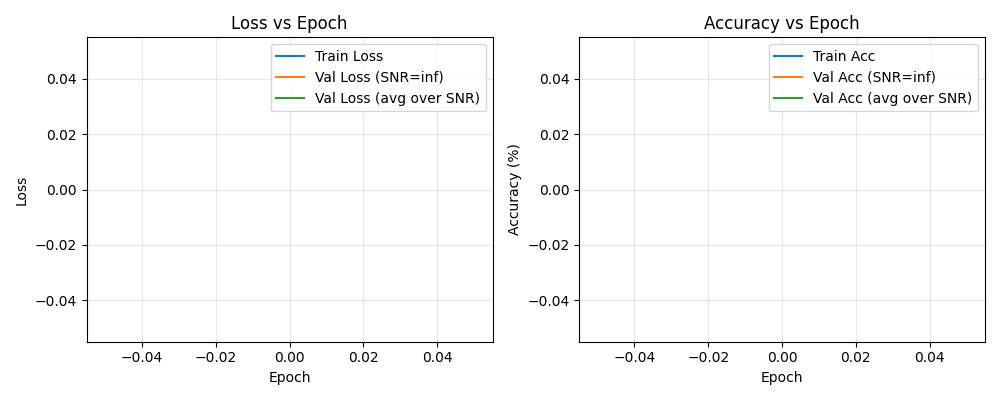

In [16]:
plot_history_with_snr_avg(history, main_val_snr=MAIN_VAL_SNR,
                          snrs_for_avg=VAL_SNR_VALUES)

In [17]:
# do a validation pass to see final performance
final_val_results = validate_model(
    model,
    val_loader,
    criterion,
    device,
    snr_values=VAL_SNR_VALUES,
    verbose=False,
)
print("Final evaluation on validation set completed.")
print("\n=== Val Accuracy per SNR ===")
for snr, stats in final_val_results.items():
    print(f"  SNR={str(snr):>6}: acc={stats['acc']:.2f}%  loss={stats['loss']:.4f}")
print("-" * 60)

Final evaluation on validation set completed.

=== Val Accuracy per SNR ===
  SNR=    -5: acc=12.18%  loss=3.3621
  SNR=     0: acc=12.25%  loss=3.3502
  SNR=     5: acc=12.09%  loss=3.3698
  SNR=    10: acc=12.23%  loss=3.4159
  SNR=    15: acc=12.25%  loss=3.4838
  SNR=   inf: acc=12.56%  loss=4.4739
------------------------------------------------------------


In [18]:
def evaluate_rank_sweep(
    model,
    compressible_layers,
    validate_fn,
    val_loader,
    criterion,
    device,
    max_rank,
    snr_values,
    step=4,
    compress_frontend=False,
    verbose=True,
    stop_at_half_rank=False,
):
    """
    Sweep across target ranks for CPC_Conv1d layers and record validation accuracy.

    Args:
        model (nn.Module): Your model containing CPC_Conv1d layers.
        compressible_layers (list[tuple[str, nn.Module]]): (name, layer) pairs of CPC_Conv1d layers.
        validate_fn (callable): Validation function (model, val_loader, criterion, device, snr_values, verbose) -> dict
        val_loader (DataLoader): Validation dataloader.
        criterion (nn.Module): Loss function.
        device (torch.device): Torch device.
        max_rank (int): Maximum rank (usually = in_channels = out_channels).
        snr_values (list): List of SNR values to evaluate.
        step (int, optional): Step size for the rank sweep. Default = 4.
        compress_frontend (bool, optional): If False, skip compressing the "frontend" layer.
        verbose (bool, optional): Print progress messages.
        stop_at_half_rank (bool, optional): If True, stop the sweep when rank > max_rank // 2.

    Returns:
        list[tuple[int, dict]]: List of (target_rank, per_noise_results) results.
    """
    val_acc_results = []

    for target_rank in range(step, max_rank + 1, step):
        if stop_at_half_rank and target_rank > (max_rank // 2):
            if verbose:
                print(f"Stopping sweep at rank {target_rank} because stop_at_half_rank=True")
            break

        # --- Activate low-rank ---
        for name, layer in compressible_layers:
            if (not compress_frontend) and (name == "frontend"):
                continue
            layer.activate_low_rank(rank=target_rank)

        # --- Validate ---
        # validate_fn is expected to be validate_model which returns a dict {snr: {acc, loss}}
        per_noise = validate_fn(model, val_loader, criterion, device, snr_values=snr_values, verbose=False)
        val_acc_results.append((target_rank, per_noise))

        if verbose:
            # Compute average accuracy for printing
            avg_acc = sum(d['acc'] for d in per_noise.values()) / len(per_noise) if per_noise else 0.0
            print(f"[Rank {target_rank:>3}] Val Acc (Avg): {avg_acc:.3f}%")
            for np_val, v in per_noise.items():
                print(f"  noise={str(np_val):>6}: acc={v['acc']:.2f}%  loss={v['loss']:.4f}")

    return val_acc_results

In [19]:
def plot_rank_vs_accuracy_by_noise(
    results,                 # list of (rank: int, per_noise: dict[noise_param -> {'acc': float, 'loss': float}])
    title=None,
    save_path=None,
    metric="acc",            # "acc" or "loss"
    show_flops=True,         # keep the secondary y-axis like before
    full_rank=None,          # <--- Added
):
    """
    Plot {metric} vs. rank with one curve per noise_param.

    Example input:
    results = [
        (4, {0.0:{'acc':14.76,'loss':4.07}, 0.05:{'acc':21.62,'loss':4.06}}),
        (8, {0.0:{'acc':20.65,'loss':4.06}, 0.05:{'acc':34.11,'loss':4.05}})
    ]
    """

    # --- collect and sort ranks ---
    ranks = sorted(int(r) for r, _ in results)
    rank_to_dict = {int(r): d for r, d in results}

    # --- gather all noise params across ranks ---
    all_noise = set()
    for d in rank_to_dict.values():
        for k in d.keys():
            try:
                all_noise.add(float(k))
            except Exception:
                # ignore non-numeric noise keys
                pass
    noise_params = sorted(all_noise)  # numeric sort

    # --- build series per noise param aligned to 'ranks' order ---
    series = {}  # noise_param -> list of metric values aligned with ranks
    for np_val in noise_params:
        vals = []
        for r in ranks:
            entry = rank_to_dict[r].get(np_val, None)
            if entry is None or metric not in entry:
                vals.append(np.nan)  # missing value creates a gap in the curve
            else:
                vals.append(entry[metric])
        series[np_val] = vals

    # --- relative FLOPs for PW conv (same as your original logic) ---
    if full_rank is not None:
        C = full_rank
    else:
        C = max(ranks) if ranks else 1

    flops_rel = [2 * r / C for r in ranks]  # =1 when r=C/2

    # --- plot ---
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # left axis: metric per noise
    for np_val, vals in series.items():
        ax1.plot(ranks, vals, marker='o', label=f"noise std={np_val:g}")

    ax1.set_xlabel("Target Rank")
    ylab = "Validation Accuracy (%)" if metric == "acc" else "Validation Loss"
    ax1.set_ylabel(ylab)
    ax1.grid(True, alpha=0.4)

    # helpful vertical reference at C//2
    ax1.axvline(x=C // 2, color='r', linestyle='--', linewidth=1, label='Max Rank // 2')

    # right axis: relative FLOPs (optional)
    if show_flops:
        ax2 = ax1.twinx()
        ax2.plot(ranks, flops_rel, linestyle='-', alpha=0.6, label="Relative PW FLOPs")
        ax2.set_ylabel("Relative PW FLOPs (vs full conv)")
        # Handle legends from both axes
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
    else:
        ax1.legend(loc="best")

    # title
    if title is None:
        base = "Validation Accuracy vs. Target Rank" if metric == "acc" \
               else "Validation Loss vs. Target Rank"
        if show_flops:
            base += " (with Relative PW FLOPs)"
        title = base
    
    title += f" (Max Rank: {C})"

    plt.title(title)

    # save or show
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"Plot saved to {save_path}")
        plt.close(fig)
    else:
        plt.tight_layout()
        plt.show()

In [20]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

def plot_rank_vs_snr_vs_accuracy_3d(results, title="Rank vs SNR vs Accuracy"):
    """
    Create a 3D plot of Rank vs SNR vs Accuracy.
    
    Args:
        results: list of (rank, per_noise_dict) tuples.
                 per_noise_dict keys are SNR values (can be float or 'inf').
                 per_noise_dict values are {'acc': float, 'loss': float}.
    """
    # Check backend to ensure interactivity
    backend = plt.get_backend()
    if 'ipympl' not in backend and 'widget' not in backend:
        print(f"Warning: Current matplotlib backend is '{backend}'. For interactive 3D plots, ensure %matplotlib widget is run and ipympl is installed.")

    ranks = []
    snrs = []
    accs = []

    for rank, per_noise in results:
        for snr, stats in per_noise.items():
            # Handle potential string 'inf' or float('inf')
            try:
                snr_val = float(snr)
            except ValueError:
                continue # Skip if not convertible to float
                
            # Ignore inf for now as requested
            if snr_val == float('inf'):
                continue
            
            ranks.append(rank)
            snrs.append(snr_val)
            accs.append(stats['acc'])

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    unique_ranks = sorted(list(set(ranks)))
    unique_snrs = sorted(list(set(snrs)))
    
    # Check if we have a complete grid to use plot_surface
    if len(ranks) > 0 and len(ranks) == len(unique_ranks) * len(unique_snrs):
        # It's a grid
        X, Y = np.meshgrid(unique_ranks, unique_snrs)
        Z = np.zeros_like(X, dtype=float)
        
        # Create a lookup for (rank, snr) -> acc
        lookup = {}
        for r, s, a in zip(ranks, snrs, accs):
            lookup[(r, s)] = a
            
        for i in range(len(unique_snrs)):
            for j in range(len(unique_ranks)):
                r = unique_ranks[j]
                s = unique_snrs[i]
                Z[i, j] = lookup.get((r, s), np.nan)
                
        surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.8)
        fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Accuracy (%)')
    else:
        # Fallback to scatter if not a perfect grid or empty
        img = ax.scatter(ranks, snrs, accs, c=accs, cmap='viridis', marker='o')
        fig.colorbar(img, ax=ax, shrink=0.5, aspect=5, label='Accuracy (%)')

    ax.set_xlabel('Model Rank')
    ax.set_ylabel('SNR Noise Level (dB)')
    ax.set_zlabel('Validation Accuracy (%)')
    ax.set_title(title)

    plt.show()

In [21]:
from thesis_project.models.blocks import CPC_Conv1d
compressible_layers = []
for name, layer in model.named_modules():
    if isinstance(layer, CPC_Conv1d):
        W = layer.weight_full.squeeze(-1)
        max_rank = min(W.shape)
        print(f"{name}: max_rank = {max_rank}")
        compressible_layers.append((name, layer))

ModuleNotFoundError: No module named 'thesis_project.models.blocks'

In [22]:
results = {}

if not SKIP_RANK_SWEEP:
    print("Running Rank Sweep (Uncompressed Frontend)...")
    results["val_acc_results"] = evaluate_rank_sweep(
        model=model,
        compressible_layers=compressible_layers,
        validate_fn=validate_model,
        val_loader=val_loader,
        criterion=criterion,    
        device=device,
        max_rank=128, #128
        snr_values=VAL_SNR_VALUES,
        step=1,
        compress_frontend=False,
        verbose=True,
        stop_at_half_rank=True
    )
    # save the results to file
    np.save(RANK_SWEEP_PATH, results)
    print(f"Rank sweep results saved to {RANK_SWEEP_PATH}")
else:
    print(f"Loading Rank Sweep (Uncompressed Frontend) from {RANK_SWEEP_PATH}...")
    try:
        loaded_results = np.load(RANK_SWEEP_PATH, allow_pickle=True).item()
        # Handle potential nesting if the file was saved with the whole dict
        if "val_acc_results" in loaded_results:
            results["val_acc_results"] = loaded_results["val_acc_results"]
        else:
            # Assume the file contains the list directly or is the dict we want
            results["val_acc_results"] = loaded_results
    except FileNotFoundError:
        print(f"Warning: {RANK_SWEEP_PATH} not found. Cannot plot uncompressed results.")
        results["val_acc_results"] = []

Loading Rank Sweep (Uncompressed Frontend) from /Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/week_10/3_stacks_keyword_spotting_rank_sweep_results.npy...


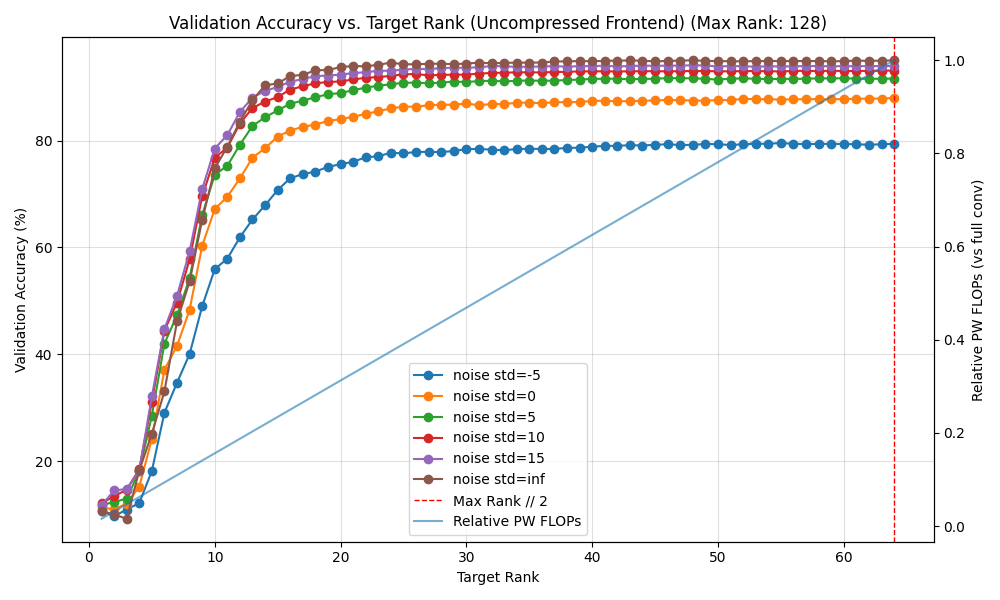

In [23]:
plot_rank_vs_accuracy_by_noise(
    results=results["val_acc_results"],
    title="Validation Accuracy vs. Target Rank (Uncompressed Frontend)",
    metric="acc",
    show_flops=True,
    full_rank=128
)

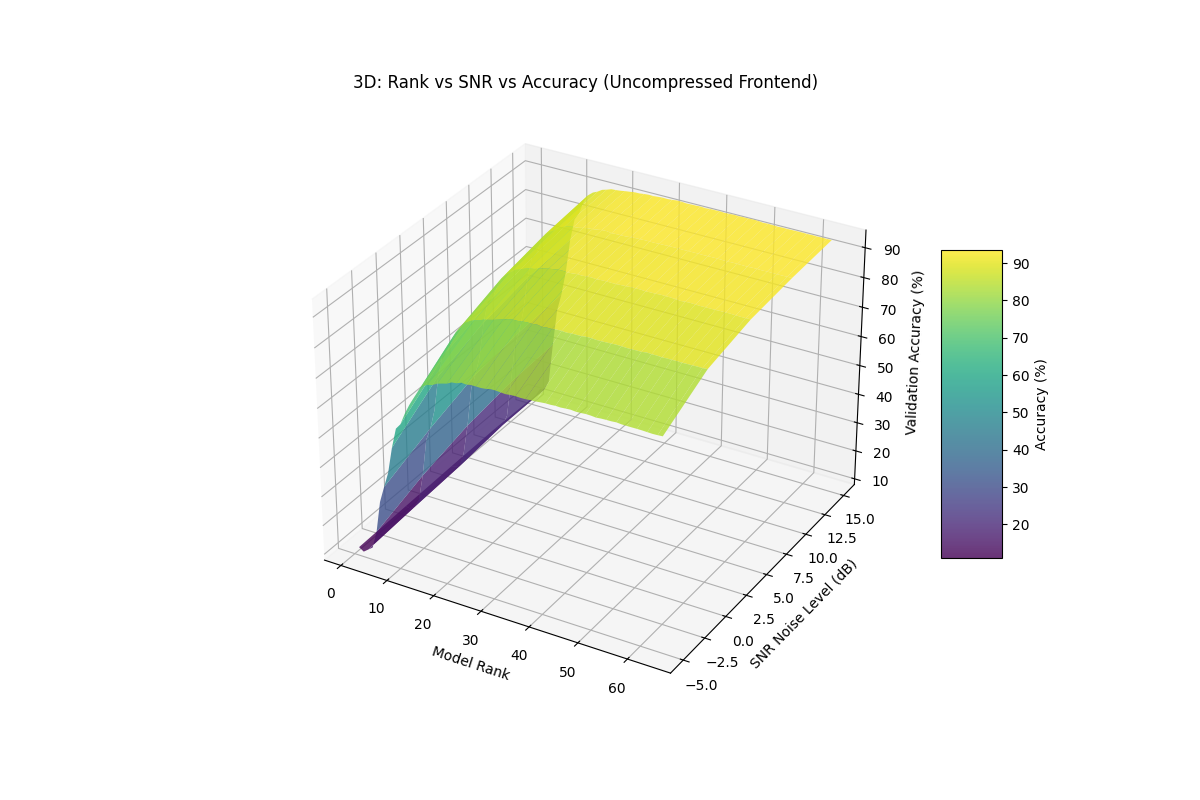

In [24]:
plot_rank_vs_snr_vs_accuracy_3d(
    results=results["val_acc_results"],
    title="3D: Rank vs SNR vs Accuracy (Uncompressed Frontend)"
)

### COMPRESSED FRONTEND RESULTS

In [25]:
if not SKIP_RANK_SWEEP_COMPRESSED:
    print("Running Rank Sweep (Compressed Frontend)...")
    results["val_acc_results_compressed_frontend"] = evaluate_rank_sweep(
        model=model,
        compressible_layers=compressible_layers,
        validate_fn=validate_model,
        val_loader=val_loader,
        criterion=criterion,    
        device=device,
        max_rank=128, #128
        snr_values=VAL_SNR_VALUES,
        step=1,
        compress_frontend=True,
        verbose=True,
        stop_at_half_rank=False
    )
    # save the results to file
    np.save(RANK_SWEEP_COMPRESSED_PATH, results)
    print(f"Rank sweep results (compressed frontend) saved to {RANK_SWEEP_COMPRESSED_PATH}")
else:
    print(f"Loading Rank Sweep (Compressed Frontend) from {RANK_SWEEP_COMPRESSED_PATH}...")
    try:
        loaded_results = np.load(RANK_SWEEP_COMPRESSED_PATH, allow_pickle=True).item()
        if "val_acc_results_compressed_frontend" in loaded_results:
            results["val_acc_results_compressed_frontend"] = loaded_results["val_acc_results_compressed_frontend"]
        else:
             pass 
    except FileNotFoundError:
        print(f"Warning: {RANK_SWEEP_COMPRESSED_PATH} not found.")
        results["val_acc_results_compressed_frontend"] = []

Loading Rank Sweep (Compressed Frontend) from /Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/week_10/3_stacks_keyword_spotting_rank_sweep_results_compressed_frontend.npy...


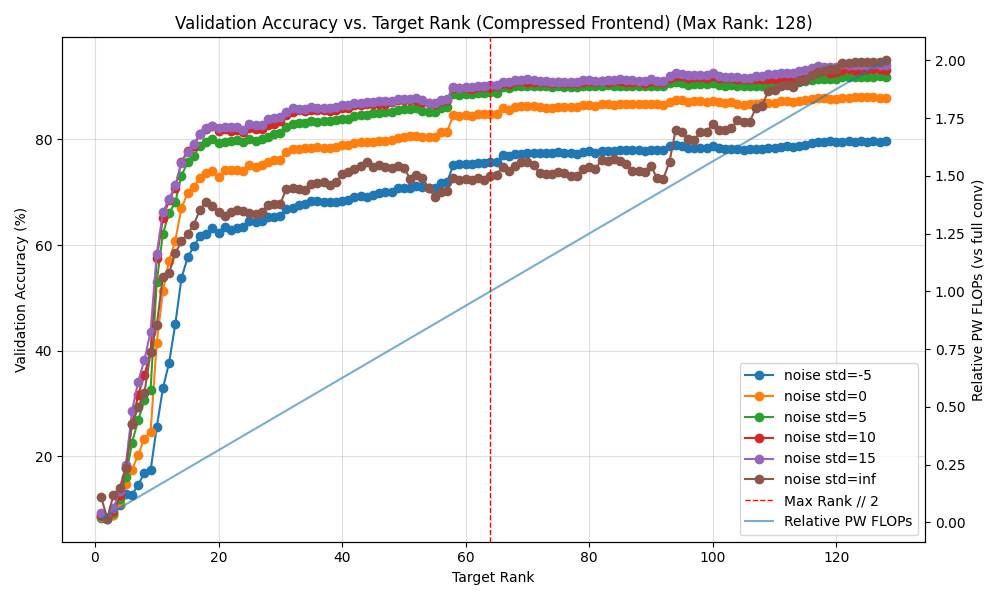

In [26]:
plot_rank_vs_accuracy_by_noise(
    results=results["val_acc_results_compressed_frontend"],
    title="Validation Accuracy vs. Target Rank (Compressed Frontend)",
    metric="acc",
    show_flops=True,
    full_rank=128
)

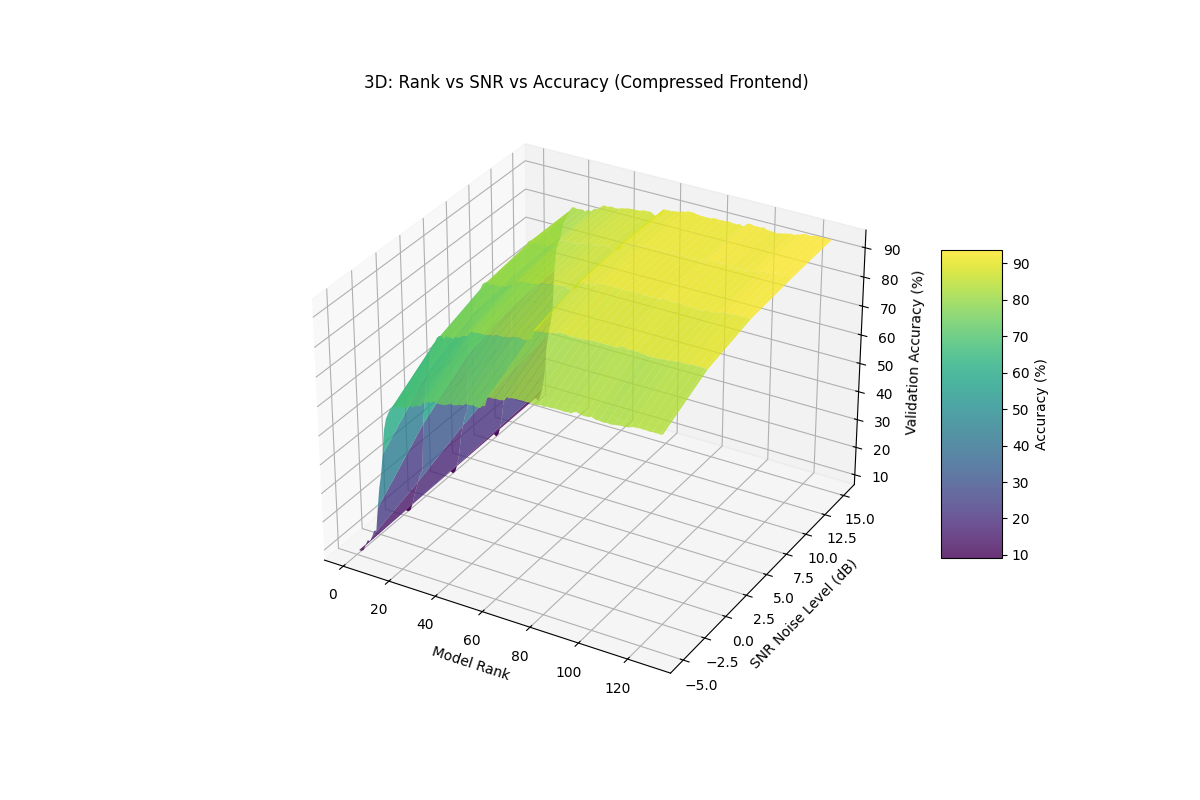

In [ ]:
plot_rank_vs_snr_vs_accuracy_3d(
    results=results["val_acc_results_compressed_frontend"],
    title="3D: Rank vs SNR vs Accuracy (Compressed Frontend)"
)